# Import library

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import torch
import time
from matplotlib.animation import FuncAnimation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd '/content/drive/MyDrive/Train Model HRC_Trần Văn Duy_20222256/Gated Recurrent Unit/conference paper'

Mounted at /content/drive
/content/drive/MyDrive/Train Model HRC_Trần Văn Duy_20222256/Gated Recurrent Unit/conference paper


# Prepare dataset

## Train dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import random

# Thiết lập seed để có thể tái tạo
np.random.seed(42)
random.seed(42)

class TrajectoryGenerator:
    def __init__(self):
        # Định nghĩa không gian làm việc (3m x 3m x 2m)
        self.workspace = {
            'x': (-1.5, 1.5),
            'y': (-0.5, 2.5),
            'z': (0.0, 2.0)
        }

        # Điểm bắt đầu
        self.start_point = np.array([0.0, 0.0, 0.0])

        # 4 điểm đích
        self.target_points = [
            np.array([0.5, 2.3, 0.4]),
            np.array([-0.6, 2.4, 0.3]),
            np.array([1.4, 2.0, 0.55]),
            np.array([-1.4, 1.9, 0.5])
        ]

        # Các chướng ngại vật ảo
        self.obstacles = [
            {'center': np.array([0.0, 1.5, 0.8]), 'radius': 0.2},
            {'center': np.array([0.5, 1.6, 0.6]), 'radius': 0.2},
            {'center': np.array([-0.4, 2.0, 0.5]), 'radius': 0.2}
        ]

        # Thông số tập dữ liệu
        self.sampling_freq = 20  # Hz
        self.duration = 10  # seconds
        self.num_samples = self.sampling_freq * self.duration
        self.noise_std = 0.02

    def sigmoid(self, t, steepness=1.2):
        """Hàm sigmoid chuẩn"""
        return 1 / (1 + np.exp(-steepness * (t - 0.5)))

    def normalize(self, values):
        """Chuẩn hóa về [0, 1]"""
        min_val = np.min(values)
        max_val = np.max(values)
        if max_val - min_val > 0:
            return (values - min_val) / (max_val - min_val)
        return values

    def generate_lift_phase(self, start, target, lift_height, num_points):
        """
        Pha nâng: Di chuyển từ start tới một điểm trung gian phía trên
        X, Y, Z đều tăng đồng thời theo sigmoid
        """
        # Tính điểm đích của pha nâng
        # X, Y: di chuyển ngẫu nhiên 25-55% về phía target (tăng độ đa dạng)
        progress_xy = np.random.uniform(0.2, 0.35)

        # Thêm độ lệch ngẫu nhiên sang trái/phải
        direction = target[:2] - start[:2]
        perp = np.array([-direction[1], direction[0]])
        if np.linalg.norm(perp) > 0:
            perp = perp / np.linalg.norm(perp)
        side_offset = np.random.uniform(-0.05, 0.05)  # Tăng độ lệch

        end_point = start.copy()
        end_point[0] = start[0] + direction[0] * progress_xy + perp[0] * side_offset
        end_point[1] = start[1] + direction[1] * progress_xy + perp[1] * side_offset
        end_point[2] = lift_height

        # Random steepness của sigmoid để tạo độ cong khác nhau
        steepness = np.random.uniform(0.8, 1.5)

        # Tạo quỹ đạo với sigmoid
        t = np.linspace(0, 1, num_points)
        progress = self.sigmoid(t, steepness=steepness)
        progress = self.normalize(progress)

        trajectory = []
        for i in range(num_points):
            p = progress[i]
            # Nội suy tuyến tính giữa start và end theo progress
            point = start + (end_point - start) * p

            # Thêm dao động nhỏ để mô phỏng rung tay
            point[2] += np.sin(p * np.pi * 3) * 0.02
            point[2] = max(0.0, point[2])

            trajectory.append(point)

        return np.array(trajectory)

    def generate_horizontal_phase(self, start, target, num_points):
        """
        Pha di chuyển ngang: từ điểm cao di chuyển về phía target
        """
        # Tính điểm đích của pha ngang (gần target nhưng vẫn cao)
        end_point = target.copy()
        end_point[2] = start[2] + np.random.uniform(-0.1, 0.05)  # Giữ độ cao tương tự hoặc hạ nhẹ
        end_point[2] = max(target[2] + 0.15, end_point[2])  # Phải cao hơn target một chút

        # Tạo điểm kiểm soát ở giữa để có đường cong
        midpoint = (start + end_point) / 2.0
        direction = end_point[:2] - start[:2]
        perp = np.array([-direction[1], direction[0], 0])
        if np.linalg.norm(perp) > 0:
            perp = perp / np.linalg.norm(perp)

        curve_offset = np.random.uniform(-0.12, 0.12)
        control_point = midpoint + perp * curve_offset
        control_point[2] = (start[2] + end_point[2]) / 2.0

        # Tạo quỹ đạo Bezier với sigmoid
        t = np.linspace(0, 1, num_points)
        progress = self.sigmoid(t, steepness=0.8)
        progress = self.normalize(progress)

        trajectory = []
        for i in range(num_points):
            p = progress[i]
            # Đường cong Bezier bậc 2
            point = (1-p)**2 * start + 2*(1-p)*p * control_point + p**2 * end_point

            # Thêm dao động nhỏ
            point[2] += np.sin(p * np.pi * 2) * 0.01
            point[2] = max(0.0, point[2])

            # Tránh chướng ngại vật
            for obs in self.obstacles:
                vec_to_obs = obs['center'] - point
                dist = np.linalg.norm(vec_to_obs)
                if dist < obs['radius'] * 1.8:
                    avoidance_strength = (obs['radius'] * 1.8 - dist) / (obs['radius'] * 1.8)
                    avoidance = -vec_to_obs / (dist + 0.01) * avoidance_strength * 0.1
                    point += avoidance
                    point[2] = max(0.0, point[2])

            trajectory.append(point)

        return np.array(trajectory)

    def generate_lower_phase(self, start, target, num_points):
        """
        Pha hạ: Di chuyển từ điểm cao xuống target
        X, Y, Z đều thay đổi đồng thời theo sigmoid
        """
        # Điểm đích chính là target
        end_point = target.copy()

        # Random steepness để tạo độ cong khác nhau
        steepness = np.random.uniform(0.8, 1.5)

        # Tạo quỹ đạo với sigmoid
        t = np.linspace(0, 1, num_points)
        progress = self.sigmoid(t, steepness=steepness)
        progress = self.normalize(progress)

        trajectory = []
        for i in range(num_points):
            p = progress[i]
            # Nội suy tuyến tính giữa start và target theo progress
            point = start + (end_point - start) * p

            # Random drift strength để tạo đa dạng
            drift_strength = np.random.uniform(0.01, 0.02)
            drift = np.sin(p * np.pi) * drift_strength
            point[0] += drift * np.random.uniform(-1, 1)
            point[1] += drift * np.random.uniform(-1, 1)

            # Thêm dao động nhỏ trên Z
            point[2] += np.sin(p * np.pi * 3) * 0.015
            point[2] = max(0.0, point[2])

            trajectory.append(point)

        # Đảm bảo điểm cuối đúng target
        trajectory[-1] = target.copy()

        return np.array(trajectory)

    def smooth_trajectory(self, trajectory):
        """Làm mượt quỹ đạo bằng moving average"""
        smoothed = trajectory.copy()
        for i in range(1, len(trajectory) - 1):
            smoothed[i] = (
                0.25 * trajectory[i-1] +
                0.50 * trajectory[i] +
                0.25 * trajectory[i+1]
            )
            smoothed[i][2] = max(0.0, smoothed[i][2])
        return smoothed

    def add_noise(self, trajectory):
        """Thêm nhiễu Gaussian"""
        noise = np.random.normal(0, self.noise_std, trajectory.shape)
        noisy_trajectory = trajectory + noise
        noisy_trajectory[:, 2] = np.maximum(0.0, noisy_trajectory[:, 2])
        return noisy_trajectory

    def generate_single_trajectory(self, target_idx):
        """Tạo một quỹ đạo hoàn chỉnh"""
        target = self.target_points[target_idx]

        # Random có 15% cơ hội tạo quỹ đạo "trực tiếp" (nâng thấp, ít giai đoạn)
        is_direct = np.random.random() < 0.15

        if is_direct:
            # Quỹ đạo trực tiếp: nâng thấp, di chuyển nhanh
            lift_ratio = np.random.uniform(0.08, 0.15)
            lower_ratio = np.random.uniform(0.08, 0.15)
            horizontal_ratio = 1.0 - lift_ratio - lower_ratio
            lift_height = np.random.uniform(0.3, 0.7)  # Nâng thấp hơn
        else:
            # Quỹ đạo thông thường với 3 pha rõ ràng
            # Pha nâng: 10-30% (nâng nhanh hoặc chậm)
            # Pha ngang: 50-70% (di chuyển chính)
            # Pha hạ: 10-30% (hạ nhanh hoặc chậm)
            lift_ratio = np.random.uniform(0.10, 0.25)
            lower_ratio = np.random.uniform(0.10, 0.25)
            horizontal_ratio = 1.0 - lift_ratio - lower_ratio

            # Đảm bảo horizontal_ratio hợp lệ (ít nhất 40%)
            if horizontal_ratio < 0.40:
                total = lift_ratio + lower_ratio
                lift_ratio = lift_ratio / total * 0.60
                lower_ratio = lower_ratio / total * 0.60
                horizontal_ratio = 0.40

            # Độ cao nâng ngẫu nhiên với khoảng rộng hơn
            lift_height = np.random.uniform(0.6, 1.5)

        num_lift = int(self.num_samples * lift_ratio)
        num_horizontal = int(self.num_samples * horizontal_ratio)
        num_lower = self.num_samples - num_lift - num_horizontal

        # Tạo 3 pha
        trajectory_lift = self.generate_lift_phase(
            self.start_point, target, lift_height, num_lift
        )

        trajectory_horizontal = self.generate_horizontal_phase(
            trajectory_lift[-1], target, num_horizontal
        )

        trajectory_lower = self.generate_lower_phase(
            trajectory_horizontal[-1], target, num_lower
        )

        # Kết hợp
        full_trajectory = np.vstack([
            trajectory_lift,
            trajectory_horizontal,
            trajectory_lower
        ])

        # Làm mượt và thêm nhiễu
        full_trajectory = self.smooth_trajectory(full_trajectory)
        full_trajectory = self.add_noise(full_trajectory)
        full_trajectory[:, 2] = np.maximum(0.0, full_trajectory[:, 2])

        # Trả về cả trajectory và các thống kê
        stats = {
            'lift_ratio': lift_ratio,
            'horizontal_ratio': horizontal_ratio,
            'lower_ratio': lower_ratio,
            'lift_height': lift_height,
            'is_direct': is_direct
        }

        return full_trajectory, target_idx, stats

    def generate_dataset(self, num_trajectories=80):
        """Tạo toàn bộ tập dữ liệu"""
        trajectories_per_target = num_trajectories // len(self.target_points)

        all_data = []
        trajectory_id = 0

        # Thống kê để kiểm tra độ đa dạng
        lift_ratios = []
        horizontal_ratios = []
        lower_ratios = []
        lift_heights = []
        direct_count = 0

        print(f"Bắt đầu tạo {num_trajectories} quỹ đạo với độ đa dạng cao...")

        for target_idx in range(len(self.target_points)):
            print(f"Đang tạo quỹ đạo cho đích {target_idx + 1}...")

            for i in range(trajectories_per_target):
                trajectory, target, stats = self.generate_single_trajectory(target_idx)
                timestamps = np.linspace(0, self.duration, self.num_samples)

                # Lưu thống kê
                lift_ratios.append(stats['lift_ratio'])
                horizontal_ratios.append(stats['horizontal_ratio'])
                lower_ratios.append(stats['lower_ratio'])
                lift_heights.append(stats['lift_height'])
                if stats['is_direct']:
                    direct_count += 1

                for t_idx, (timestamp, point) in enumerate(zip(timestamps, trajectory)):
                    all_data.append({
                        'trajectory_id': trajectory_id,
                        'timestamp': timestamp,
                        'sample_idx': t_idx,
                        'x': point[0],
                        'y': point[1],
                        'z': point[2],
                        'target_id': target
                    })

                trajectory_id += 1

        print("Hoàn thành tạo dữ liệu!")

        df = pd.DataFrame(all_data)
        print(f"\n=== THỐNG KÊ DỮ LIỆU ===")
        print(f"\nZ coordinate:")
        print(f"  Min Z: {df['z'].min():.4f} m")
        print(f"  Max Z: {df['z'].max():.4f} m")
        print(f"  Mean Z: {df['z'].mean():.4f} m")

        print(f"\nĐộ đa dạng của các pha:")
        print(f"  Lift ratio: {np.min(lift_ratios):.2%} - {np.max(lift_ratios):.2%} (TB: {np.mean(lift_ratios):.2%})")
        print(f"  Horizontal ratio: {np.min(horizontal_ratios):.2%} - {np.max(horizontal_ratios):.2%} (TB: {np.mean(horizontal_ratios):.2%})")
        print(f"  Lower ratio: {np.min(lower_ratios):.2%} - {np.max(lower_ratios):.2%} (TB: {np.mean(lower_ratios):.2%})")
        print(f"  Lift height: {np.min(lift_heights):.2f} - {np.max(lift_heights):.2f} m (TB: {np.mean(lift_heights):.2f} m)")
        print(f"\nSố quỹ đạo trực tiếp (nâng thấp): {direct_count}/{num_trajectories} ({direct_count/num_trajectories:.1%})")

        return df

# Tạo generator và sinh dữ liệu
generator = TrajectoryGenerator()
dataset = generator.generate_dataset(num_trajectories=200)

# Lưu dataset
output_file = 'human_robot_cocarrying_trajectories.csv'
dataset.to_csv(output_file, index=False)
print(f"\nĐã lưu dataset vào: {output_file}")
print(f"Kích thước dataset: {dataset.shape}")
print(f"Số quỹ đạo: {dataset['trajectory_id'].nunique()}")
print(f"Số mẫu mỗi quỹ đạo: {len(dataset[dataset['trajectory_id'] == 0])}")

Bắt đầu tạo 200 quỹ đạo với độ đa dạng cao...
Đang tạo quỹ đạo cho đích 1...
Đang tạo quỹ đạo cho đích 2...
Đang tạo quỹ đạo cho đích 3...
Đang tạo quỹ đạo cho đích 4...
Hoàn thành tạo dữ liệu!

=== THỐNG KÊ DỮ LIỆU ===

Z coordinate:
  Min Z: 0.0000 m
  Max Z: 1.5798 m
  Mean Z: 0.8309 m

Độ đa dạng của các pha:
  Lift ratio: 8.53% - 24.92% (TB: 16.81%)
  Horizontal ratio: 51.36% - 83.01% (TB: 66.20%)
  Lower ratio: 8.31% - 24.73% (TB: 16.99%)
  Lift height: 0.33 - 1.50 m (TB: 0.96 m)

Số quỹ đạo trực tiếp (nâng thấp): 26/200 (13.0%)

Đã lưu dataset vào: human_robot_cocarrying_trajectories.csv
Kích thước dataset: (40000, 7)
Số quỹ đạo: 200
Số mẫu mỗi quỹ đạo: 200


## Visualization


=== VẼ 5 QUỸ ĐẠO NGẪU NHIÊN ===


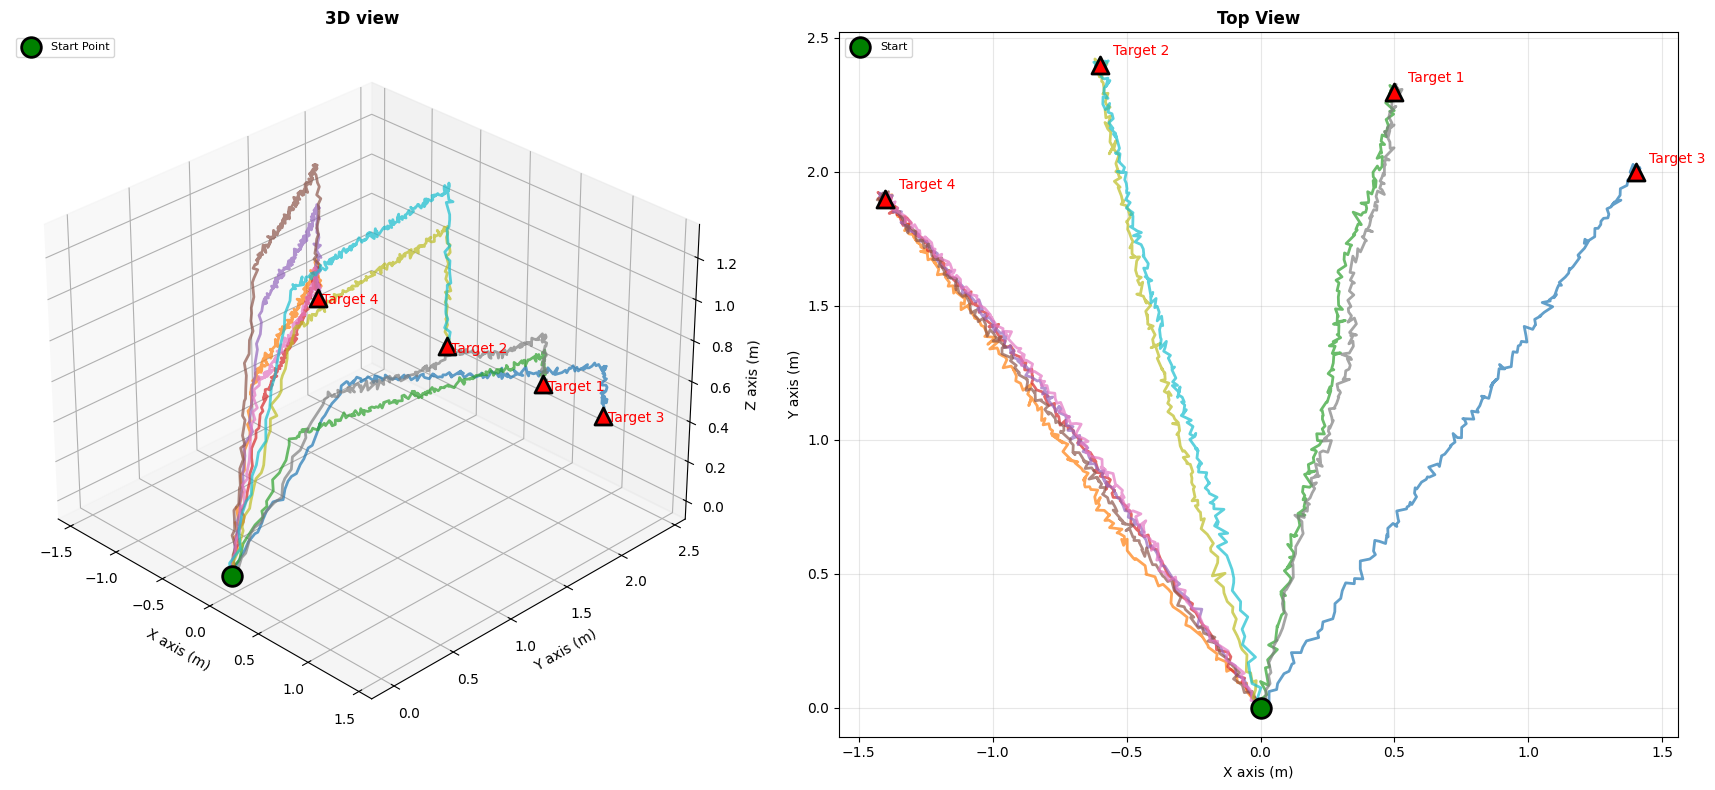

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import interp1d
import random

# Re-initialize the generator to ensure it's available and has the correct parameters
# The TrajectoryGenerator class was defined in cell RxCOinBv4rF7, so it should be in scope.
generator = TrajectoryGenerator()

# Load the dataset as a DataFrame from the saved CSV
output_file = 'human_robot_cocarrying_trajectories.csv'
dataset = pd.read_csv(output_file)

# Vẽ 5 quỹ đạo ngẫu nhiên để trực quan hóa
print("\n=== VẼ 5 QUỸ ĐẠO NGẪU NHIÊN ===")

# Chọn ngẫu nhiên 5 trajectory_id
all_trajectory_ids = dataset['trajectory_id'].unique()
random_trajectory_ids = np.random.choice(all_trajectory_ids, size=10, replace=False)

# Tạo figure với 2 góc nhìn
fig = plt.figure(figsize=(18, 8))

# Góc nhìn 1: 3D perspective
ax1 = fig.add_subplot(121, projection='3d')

# Cài đặt góc nhìn 3D (chéo từ trên xuống, điểm bắt đầu bên trái, đích bên phải)
ax1.view_init(elev=30, azim=-45)

colors = plt.cm.tab10(np.linspace(0, 1, 10)) # Chỉ cần 5 màu cho 5 quỹ đạo

for idx, traj_id in enumerate(random_trajectory_ids):
    traj_data = dataset[dataset['trajectory_id'] == traj_id]
    x = traj_data['x'].values
    y = traj_data['y'].values
    z = traj_data['z'].values
    # target_id = traj_data['target_id'].iloc[0] # Not needed for legend anymore

    # Vẽ quỹ đạo, không có label chi tiết từng quỹ đạo
    ax1.plot(x, y, z, color=colors[idx], linewidth=2, alpha=0.7)

    # Không vẽ điểm bắt đầu và kết thúc riêng lẻ cho từng quỹ đạo
    # ax1.scatter(x[0], y[0], z[0], color=colors[idx], s=100, marker='o', edgecolors='black')
    # ax1.scatter(x[-1], y[-1], z[-1], color=colors[idx], s=100, marker='s', edgecolors='black')

# Vẽ điểm bắt đầu (hình tròn màu xanh)
ax1.scatter(*generator.start_point, color='green', s=200, marker='o',
           edgecolors='black', linewidths=2, label='Start Point', zorder=10)

# Vẽ các điểm đích (tam giác màu đỏ) và gắn nhãn
for i, target in enumerate(generator.target_points):
    ax1.scatter(*target, color='red', s=150, marker='^',
               edgecolors='black', linewidths=2, zorder=10) # Không có label trong legend
    # Ghi chú thích bên dưới chân các điểm đích
    ax1.text(target[0] + 0.05, target[1], target[2], f'Target {i+1}', color='red', fontsize=10, ha='left', va='center')

ax1.set_xlabel('X axis (m)', fontsize=10)
ax1.set_ylabel('Y axis (m)', fontsize=10)
ax1.set_zlabel('Z axis (m)', fontsize=10)
ax1.set_title('3D view', fontsize=12, fontweight='bold') # Cập nhật tiêu đề
ax1.legend(fontsize=8, loc='upper left') # Legend chỉ bao gồm Start Point
ax1.grid(True, alpha=0.3)

# Góc nhìn 2: Top view (X-Y plane)
ax2 = fig.add_subplot(122)

for idx, traj_id in enumerate(random_trajectory_ids):
    traj_data = dataset[dataset['trajectory_id'] == traj_id]
    x = traj_data['x'].values
    y = traj_data['y'].values
    # target_id = traj_data['target_id'].iloc[0] # Not needed for legend anymore

    ax2.plot(x, y, color=colors[idx], linewidth=2, alpha=0.7)

    # Không vẽ điểm bắt đầu và kết thúc riêng lẻ cho từng quỹ đạo
    # ax2.scatter(x[0], y[0], color=colors[idx], s=100, marker='o', edgecolors='black')
    # ax2.scatter(x[-1], y[-1], color=colors[idx], s=100, marker='s', edgecolors='black')

# Vẽ điểm bắt đầu
ax2.scatter(generator.start_point[0], generator.start_point[1],
           color='green', s=200, marker='o', edgecolors='black', linewidths=2, label='Start', zorder=10)

# Vẽ các điểm đích và gắn nhãn
for i, target in enumerate(generator.target_points):
    ax2.scatter(target[0], target[1], color='red', s=150, marker='^',
               edgecolors='black', linewidths=2, zorder=10) # Không có label trong legend
    ax2.text(target[0] + 0.05, target[1] + 0.05, f'Target {i+1}', color='red', fontsize=10, ha='left', va='center')

ax2.set_xlabel('X axis (m)', fontsize=10)
ax2.set_ylabel('Y axis (m)', fontsize=10)
ax2.set_title('Top View', fontsize=12, fontweight='bold') # Cập nhật tiêu đề
ax2.legend(fontsize=8, loc='upper left') # Legend chỉ bao gồm Start Point
ax2.grid(True, alpha=0.3)
ax2.axis('equal')

plt.tight_layout()
plt.show()


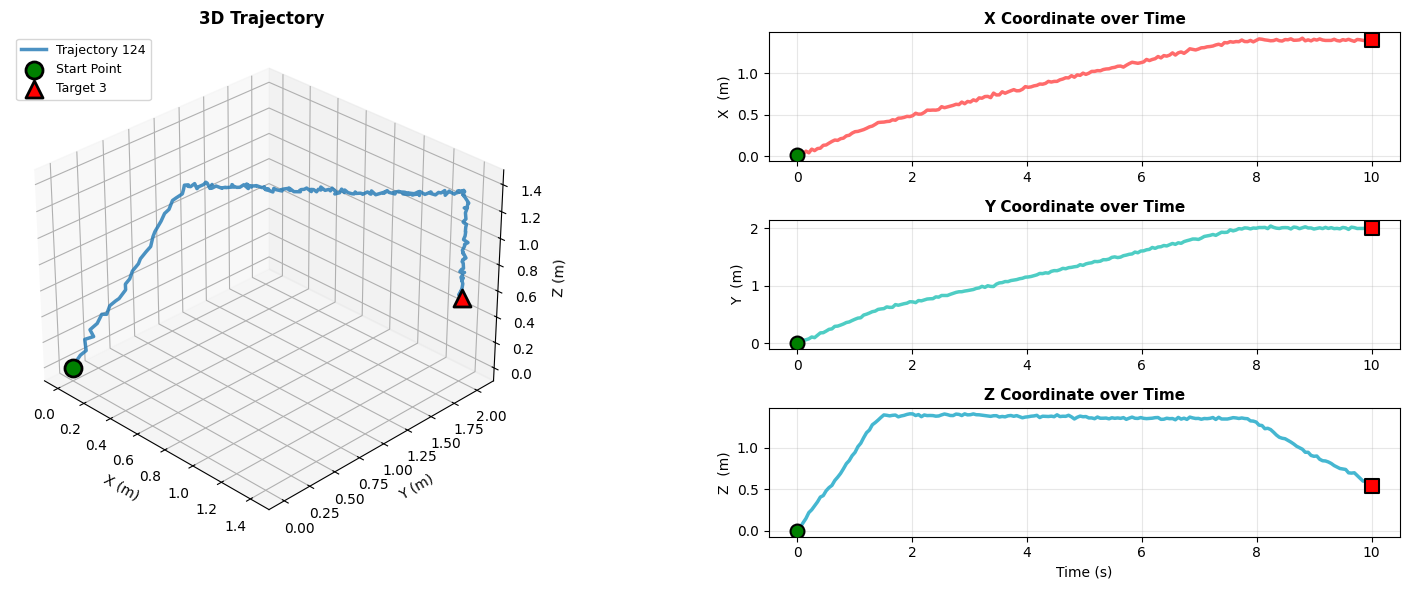

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec

# Load the dataset
dataset = pd.read_csv('human_robot_cocarrying_trajectories.csv')

# Define start and target points (from TrajectoryGenerator or previous cells)
start_point = np.array([0, 0, 0])
target_points = [
    np.array([0.5, 2.3, 0.4]),   # Target 1
    np.array([-0.6, 2.4, 0.3]),   # Target 2
    np.array([1.4, 2, 0.55]),   # Target 3
    np.array([-1.4, 1.9, 0.5])    # Target 4
]

# Select a random trajectory
all_trajectory_ids = dataset['trajectory_id'].unique()
random_traj_id = np.random.choice(all_trajectory_ids)
traj_data = dataset[dataset['trajectory_id'] == random_traj_id]

timestamps = traj_data['timestamp'].values
x_coords = traj_data['x'].values
y_coords = traj_data['y'].values
z_coords = traj_data['z'].values
target_idx_of_traj = traj_data['target_id'].iloc[0] # Get the target ID for this trajectory
end_point_of_traj = target_points[target_idx_of_traj] # Get the specific target coordinates

# Create figure and a GridSpec layout
fig = plt.figure(figsize=(18, 6)) # Adjust figure size as needed
gs = gridspec.GridSpec(3, 2, width_ratios=[2, 1]) # 3 rows, 2 columns, 3D plot is wider

# --- 3D Trajectory Plot ---
ax_3d = fig.add_subplot(gs[:, 0], projection='3d') # Span all 3 rows in the first column

# Plot the trajectory
ax_3d.plot(x_coords, y_coords, z_coords, color='#1f77b4', linewidth=2.5, alpha=0.8, label=f'Trajectory {random_traj_id}')

# Plot start point (circle)
ax_3d.scatter(*start_point, color='green', s=150, marker='o', edgecolors='black', linewidths=2, label='Start Point', zorder=5)

# Plot end point (triangle)
ax_3d.scatter(*end_point_of_traj, color='red', s=150, marker='^', edgecolors='black', linewidths=2, label=f'Target {target_idx_of_traj+1}', zorder=5)

# Set view angle as requested: elev=30 for an aerial view, azim=-45 to place start on left and end on right
ax_3d.view_init(elev=30, azim=-45) # Elevation 30-45, Azimuth -45 for left-to-right view

ax_3d.set_xlabel('X (m)', fontsize=10)
ax_3d.set_ylabel('Y (m)', fontsize=10)
ax_3d.set_zlabel('Z (m)', fontsize=10)
ax_3d.set_title(f'3D Trajectory', fontsize=12, fontweight='bold')
ax_3d.legend(fontsize=9, loc='upper left')
ax_3d.grid(True, alpha=0.3)

# --- 2D Coordinate Plots (X, Y, Z) ---
colors_2d = ['#FF6B6B', '#4ECDC4', '#45B7D1'] # Custom colors for X, Y, Z

coords = [x_coords, y_coords, z_coords]
labels = ['X  (m)', 'Y  (m)', 'Z  (m)']
titles = ['X Coordinate over Time', 'Y Coordinate over Time', 'Z Coordinate over Time']

for i in range(3):
    ax_2d = fig.add_subplot(gs[i, 1]) # Each 2D plot in its row in the second column
    ax_2d.plot(timestamps, coords[i], color=colors_2d[i], linewidth=2.5)

    # Mark start point
    ax_2d.scatter(timestamps[0], coords[i][0], color='green', s=100, marker='o', edgecolors='black', linewidths=1.5, zorder=5)
    # Mark end point
    ax_2d.scatter(timestamps[-1], coords[i][-1], color='red', s=100, marker='s', edgecolors='black', linewidths=1.5, zorder=5)

    ax_2d.set_ylabel(labels[i], fontsize=10)
    ax_2d.set_title(titles[i], fontsize=11, fontweight='bold')
    ax_2d.grid(True, alpha=0.3)

# Set xlabel only for the bottom 2D plot
ax_2d.set_xlabel('Time (s)', fontsize=10)

plt.tight_layout()
plt.show()


## Test dataset

In [ ]:
# Tạo generator và sinh dữ liệu
generator = TrajectoryGenerator()
dataset = generator.generate_dataset(num_trajectories=40)

# Lưu dataset
output_file = 'data_test.csv'
dataset.to_csv(output_file, index=False)
print(f"\nĐã lưu dataset vào: {output_file}")
print(f"Kích thước dataset: {dataset.shape}")
print(f"Số quỹ đạo: {dataset['trajectory_id'].nunique()}")
print(f"Số mẫu mỗi quỹ đạo: {len(dataset[dataset['trajectory_id'] == 0])}")


Bắt đầu tạo 40 quỹ đạo với độ đa dạng cao...
Đang tạo quỹ đạo cho đích 1...
Đang tạo quỹ đạo cho đích 2...
Đang tạo quỹ đạo cho đích 3...
Đang tạo quỹ đạo cho đích 4...
Hoàn thành tạo dữ liệu!

=== THỐNG KÊ DỮ LIỆU ===

Z coordinate:
  Min Z: 0.0000 m
  Max Z: 1.5148 m
  Mean Z: 0.8337 m

Độ đa dạng của các pha:
  Lift ratio: 10.30% - 24.76% (TB: 16.22%)
  Horizontal ratio: 54.24% - 77.01% (TB: 66.13%)
  Lower ratio: 8.43% - 24.03% (TB: 17.65%)
  Lift height: 0.46 - 1.50 m (TB: 0.96 m)

Số quỹ đạo trực tiếp (nâng thấp): 3/40 (7.5%)

Đã lưu dataset vào: data_test.csv
Kích thước dataset: (8000, 7)
Số quỹ đạo: 40
Số mẫu mỗi quỹ đạo: 200


# Model 1: Model Seq2One


## Build model

In [ ]:
import pandas as pd
import numpy as np
import pickle
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import GRU, Dense, Dropout, GRUCell # Import GRUCell
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.layers import RNN, SimpleRNN, Dense, Dropout # Import SimpleRNN
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np

# Tham số
NUM_FEATURES=3
T = 20             # Input length
PRED_STEPS = 180    # Số bước cần dự đoán
MODEL_PATH = 'Deep_GRU.keras'
SCALER_X_PATH_1 = 'scaler_x.pkl'
SCALER_Y_PATH_1 = 'scaler_y.pkl'
SEQUENCE_LENGTH = T + PRED_STEPS

def load_data(file_path):
    df = pd.read_csv(file_path)
    return df[['x', 'y', 'z']].values

def create_data(data, T, sequence_length):
    X, y = [], []
    num_trajectories = len(data) // sequence_length
    print(f"Số lượng quỹ đạo: {num_trajectories}")

    for i in range(num_trajectories):
        # Lấy dữ liệu cho quỹ đạo thứ i
        trajectory = data[i*sequence_length : (i+1)*sequence_length]

        # Kiểm tra kích thước
        if trajectory.shape != (sequence_length, 3):
            continue

        # Tạo các chuỗi đầu vào và đầu ra từ quỹ đạo
        for j in range(sequence_length):
            if j < T:
                # Với t < T: pad zero vào phía trước
                num_zeros = T - j  # Số zero vectors cần thêm
                num_real_points = j  # Số điểm thực có

                # Tạo zero padding
                zero_padding = np.zeros((num_zeros, 3))

                # Lấy các điểm thực từ đầu quỹ đạo đến j-1
                if num_real_points > 0:
                    real_points = trajectory[0:j]
                    input_sequence = np.vstack([zero_padding, real_points])
                else:
                    # Trường hợp j=0, chỉ có zero padding
                    input_sequence = zero_padding

                # Output là điểm tiếp theo
                output_point = trajectory[j]

            else:
                # Với t >= T: lấy T điểm liên tiếp như bình thường
                input_sequence = trajectory[j-T:j]
                output_point = trajectory[j]

            X.append(input_sequence)
            y.append(output_point)

    X = np.array(X)
    y = np.array(y)

    print(f"Shape của X: {X.shape}")  # (num_samples, T, 3)
    print(f"Shape của y: {y.shape}")  # (num_samples, 3)

    return X, y

def scale_data(X, y):
    """
    Scale riêng từng trục (x, y, z) để đảm bảo mỗi trục có range [0, 1]

    Args:
        X: (num_samples, T, 3) - input sequences
        y: (num_samples, 3) - target positions

    Returns:
        X_scaled, y_scaled, scaler_x, scaler_y
    """
    # Tạo 3 scalers riêng biệt cho 3 trục
    scaler_x = {
        'x': MinMaxScaler(),
        'y': MinMaxScaler(),
        'z': MinMaxScaler()
    }

    scaler_y = {
        'x': MinMaxScaler(),
        'y': MinMaxScaler(),
        'z': MinMaxScaler()
    }

    # Scale X (input sequences) - từng trục riêng biệt
    X_scaled = X.copy()
    num_samples, T, _ = X.shape

    # Scale trục X (chiều 0)
    X_scaled[:, :, 0] = scaler_x['x'].fit_transform(X[:, :, 0].reshape(-1, 1)).reshape(num_samples, T)
    # Scale trục Y (chiều 1)
    X_scaled[:, :, 1] = scaler_x['y'].fit_transform(X[:, :, 1].reshape(-1, 1)).reshape(num_samples, T)
    # Scale trục Z (chiều 2)
    X_scaled[:, :, 2] = scaler_x['z'].fit_transform(X[:, :, 2].reshape(-1, 1)).reshape(num_samples, T)

    # Scale y (target) - từng trục riêng biệt
    y_scaled = y.copy()
    y_scaled[:, 0] = scaler_y['x'].fit_transform(y[:, 0].reshape(-1, 1)).ravel()
    y_scaled[:, 1] = scaler_y['y'].fit_transform(y[:, 1].reshape(-1, 1)).ravel()
    y_scaled[:, 2] = scaler_y['z'].fit_transform(y[:, 2].reshape(-1, 1)).ravel()

    return X_scaled, y_scaled, scaler_x, scaler_y

def build_model(input_shape):
    model = Sequential([
        GRU(256, activation='tanh', return_sequences=True, input_shape=input_shape), # Use SimpleRNN
        Dropout(0.1),
        GRU(128, activation='tanh'), # Use SimpleRNN
        Dropout(0.1),
        Dense(3)
    ])
    model.compile(optimizer=Adam(0.001), loss='mse')
    return model

def save_model_and_scalers(model, scaler_x, scaler_y, model_path, scaler_x_path, scaler_y_path):
    model.save(model_path)
    with open(scaler_x_path, 'wb') as f:
        pickle.dump(scaler_x, f)
    with open(scaler_y_path, 'wb') as f:
        pickle.dump(scaler_y, f)
    print(f"Model saved to {model_path}")
    print(f"Scalers saved to {scaler_x_path} and {scaler_y_path}")

In [ ]:
# === Đào tạo ===
from sklearn.model_selection import train_test_split # Import train_test_split

data = load_data('/content/drive/MyDrive/Train Model HRC_Trần Văn Duy_20222256/Gated Recurrent Unit/conference paper/human_robot_cocarrying_trajectories.csv')
X, y = create_data(data, T, SEQUENCE_LENGTH)
X_scaled, y_scaled, scaler_x, scaler_y = scale_data(X, y)
X_train, X_val, y_train, y_val = train_test_split(
        X_scaled,               # Dữ liệu input đầy đủ đã scale
        y_scaled,               # Dữ liệu output đầy đủ đã scale
        test_size=0.2,          # 20% cho validation
        random_state=42,        # Để kết quả lặp lại được
        shuffle=True            # Xáo trộn dữ liệu
    )
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape},   y_val:   {y_val.shape}")
model = build_model((T, 3))
model.summary()

Số lượng quỹ đạo: 80
Shape của X: (16000, 20, 3)
Shape của y: (16000, 3)
  X_train: (12800, 20, 3), y_train: (12800, 3)
  X_val:   (3200, 20, 3),   y_val:   (3200, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 20, 256)        │       200,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │       148,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 349,059 (1.33 MB)

 Trainable params: 349,059 (1.33 MB)

 Non-trainable params: 0 (0.00 B)

## Train model

In [ ]:
# === Đào tạo ===
from sklearn.model_selection import train_test_split # Import train_test_split
import time
import psutil
import os

# Record RAM usage before GRU training
gru_ram_before = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
print(f"RAM usage before GRU training: {gru_ram_before:.2f} MB")


# Record start time for GRU training
gru_train_start_time = time.time()

history = model.fit(
    X_train, y_train,                 # Sử dụng tập train đã chia
    epochs=300,                       # Số epochs (có thể điều chỉnh)
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', patience=7, factor=0.5, verbose=1)
    ],
    verbose=1
)

# Record end time for GRU training
gru_train_end_time = time.time()
gru_total_train_time = gru_train_end_time - gru_train_start_time
print(f"\nGRU Model Training Time: {gru_total_train_time:.4f} seconds")

# Record RAM usage after GRU training
gru_ram_after = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
print(f"RAM usage after GRU training: {gru_ram_after:.2f} MB")
print(f"RAM used by GRU training: {gru_ram_after - gru_ram_before:.2f} MB")

RAM usage before GRU training: 1430.18 MB
Epoch 1/300
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0145 - val_loss: 4.2445e-04 - learning_rate: 0.0010
Epoch 2/300
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0017 - val_loss: 3.1768e-04 - learning_rate: 0.0010
Epoch 3/300
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0013 - val_loss: 2.9786e-04 - learning_rate: 0.0010
Epoch 4/300
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0011 - val_loss: 4.6246e-04 - learning_rate: 0.0010
Epoch 5/300
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0011 - val_loss: 3.1428e-04 - learning_rate: 0.0010
Epoch 6/300
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 9.4809e-04 - val_loss: 2.9313e-04 - learning_rate: 0.0010
Epoch 7/300
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 8.4648e-04 - val_loss: 2.3113e-04 - learning_rate: 0.0010
Epoch 8/300
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 8.5189e-04 - val_loss: 2.3625e-04 - learning_rate: 0.0010
Epoch 9/300
494/500 ━━━━

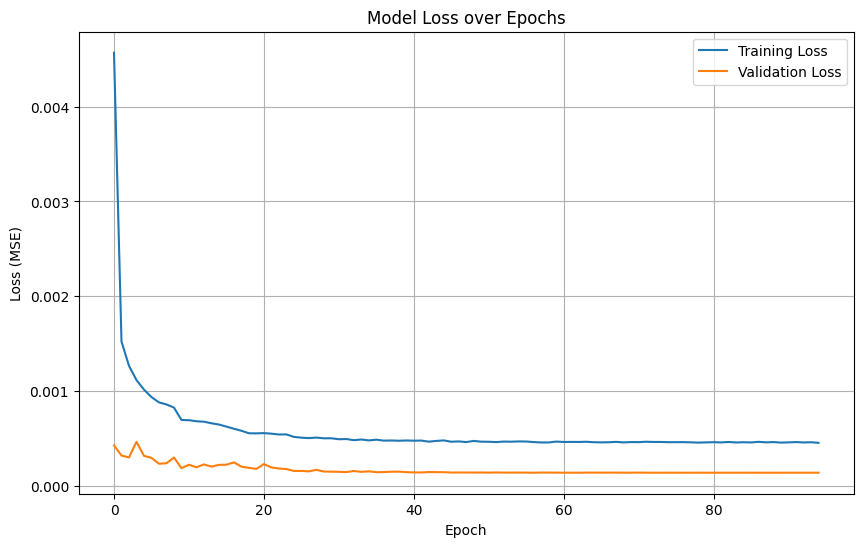

In [ ]:
# Vẽ đồ thị Loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()



## Save model

In [ ]:
import os
save_model_and_scalers(model, scaler_x, scaler_y, MODEL_PATH, SCALER_X_PATH_1, SCALER_Y_PATH_1)

Model saved to Deep_GRU.keras
Scalers saved to scaler_x.pkl and scaler_y.pkl


## Build Predict and Plot function

In [ ]:
# --- Hàm Dự đoán Online Kiểu Assistive (Input GT, Dự đoán từ đầu) ---
def predict_assistive_gt_input_from_zero(model,
                                         scaler_x,
                                         scaler_y,
                                         ground_truth):

    predictions = []
    predictions.append(ground_truth[0].copy())
    prediction_times = []
    overall_pred_start_time = time.time()

    # Khởi tạo input sequence ban đầu là vector 0
    input_seq = np.zeros((T, NUM_FEATURES), dtype=np.float32)
    input_seq[-1] = ground_truth[0].copy()

    # Dự đoán cho từng bước thời gian
    for i in range(len(ground_truth) - 1):
        # Sử dụng input_seq hiện tại
        current_input = input_seq.copy()

        # Chuẩn hóa input - scale riêng từng trục
        input_scaled = current_input.copy()
        input_scaled[:, 0] = scaler_x['x'].transform(current_input[:, 0].reshape(-1, 1)).ravel()
        input_scaled[:, 1] = scaler_x['y'].transform(current_input[:, 1].reshape(-1, 1)).ravel()
        input_scaled[:, 2] = scaler_x['z'].transform(current_input[:, 2].reshape(-1, 1)).ravel()
        input_scaled = input_scaled.reshape(1, T, NUM_FEATURES)

        # Dự đoán
        step_start_time = time.time()
        pred_scaled = model.predict(input_scaled, verbose=0)
        step_end_time = time.time()
        prediction_times.append(step_end_time - step_start_time)

        # Inverse transform - scale riêng từng trục
        prediction = np.zeros(NUM_FEATURES)
        prediction[0] = scaler_y['x'].inverse_transform(pred_scaled[0, 0].reshape(-1, 1))[0, 0]
        prediction[1] = scaler_y['y'].inverse_transform(pred_scaled[0, 1].reshape(-1, 1))[0, 0]
        prediction[2] = scaler_y['z'].inverse_transform(pred_scaled[0, 2].reshape(-1, 1))[0, 0]

        # Lưu dự đoán
        predictions.append(prediction)

        # Cập nhật input sequence cho bước tiếp theo bằng ground truth
        input_seq = np.vstack([input_seq[1:], ground_truth[i + 1].reshape(1, NUM_FEATURES)])

    overall_pred_end_time = time.time()
    total_prediction_time = overall_pred_end_time - overall_pred_start_time
    print(f"Dự đoán hoàn tất sau {total_prediction_time:.4f} giây.")

    return np.array(predictions), prediction_times, total_prediction_time

# --- Hàm Vẽ Đồ Thị So Sánh Assistive 3D ---
def plot_assistive_prediction_3d(ground_truth_xyz, predicted_xyz):
    """
    Vẽ so sánh quỹ đạo ground truth 3D và dự đoán kiểu assistive 3D.

    Args:
        ground_truth_xyz (np.ndarray): Toàn bộ quỹ đạo gốc [x, y, z]. Shape (N, 3).
        predicted_xyz (np.ndarray): Chuỗi điểm dự đoán [x, y, z]. Shape (N-1, 3).
                                     predicted_xyz[i] là dự đoán cho điểm ground_truth_xyz[i+1].
        title (str): Tiêu đề cho đồ thị.
    """
    N = len(ground_truth_xyz)
    num_predictions = len(predicted_xyz)

    # Trục thời gian
    time_steps_full_gt = np.arange(N)
    time_steps_prediction = np.arange(num_predictions)

    fig, axs = plt.subplots(1, NUM_FEATURES, figsize=(18, 4), sharex=True) # 3 subplots in one row
    titles = ['X Coordinate', 'Y Coordinate', 'Z Coordinate']


    for i in range(NUM_FEATURES):
        # Vẽ Ground Truth (toàn bộ)
        axs[i].plot(time_steps_full_gt, ground_truth_xyz[:, i], label='Ground Truth (Human Intention)', linestyle='--', color='green', alpha=0.7)

        # Vẽ Dự đoán (bắt đầu từ bước 1)
        axs[i].plot(time_steps_prediction, predicted_xyz[:, i], label='Model Prediction (for next step)',linestyle='--', color='red', markersize=3, alpha=0.9)
        axs[i].set_ylabel('Coordinate')
        axs[i].legend(loc='best')
        axs[i].grid(True)

    axs[1].set_xlabel('Time Step') # Set xlabel for the middle plot
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

## Load model and predict trajactory

Số lượng quỹ đạo: 60
Shape của X: (12000, 20, 3)
Shape của y: (12000, 3)
Loss on test data: 0.008800932206213474
Dự đoán hoàn tất sau 12.8418 giây.
Quỹ đạo : Tổng thời gian dự đoán chuỗi: 12.841755 giây
Quỹ đạo : Thời gian dự đoán trung bình mỗi bước: 0.063642 giây


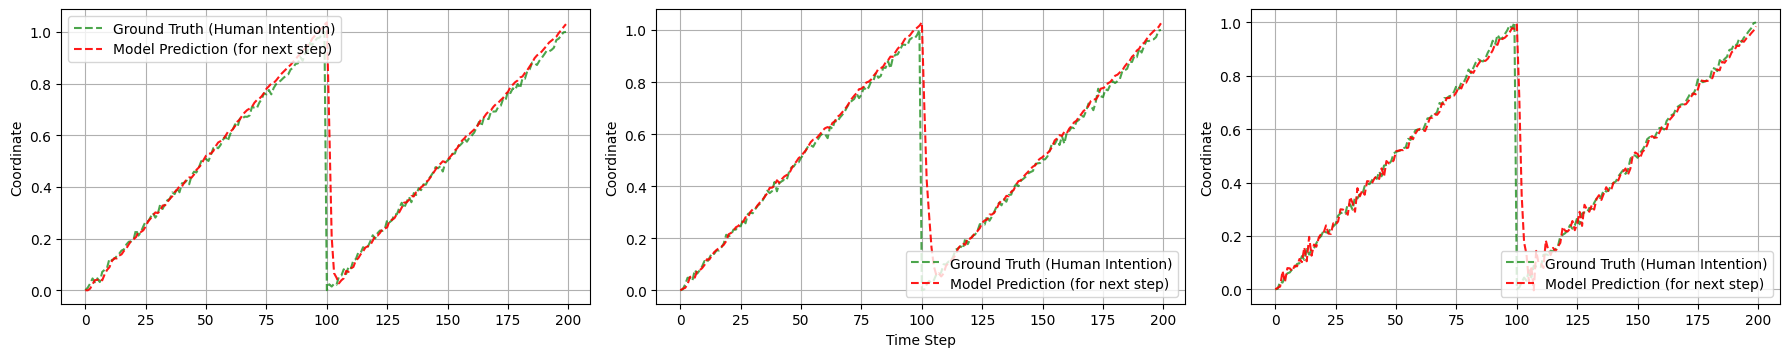

Dự đoán hoàn tất sau 12.7787 giây.
Quỹ đạo : Tổng thời gian dự đoán chuỗi: 12.778683 giây
Quỹ đạo : Thời gian dự đoán trung bình mỗi bước: 0.063318 giây


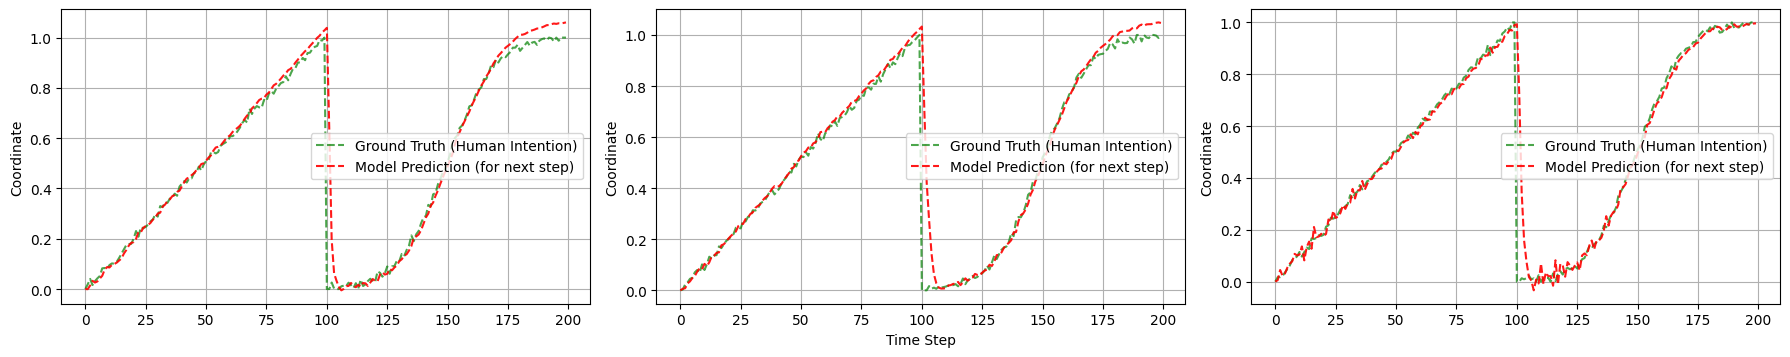

Dự đoán hoàn tất sau 12.7845 giây.
Quỹ đạo : Tổng thời gian dự đoán chuỗi: 12.784545 giây
Quỹ đạo : Thời gian dự đoán trung bình mỗi bước: 0.063348 giây


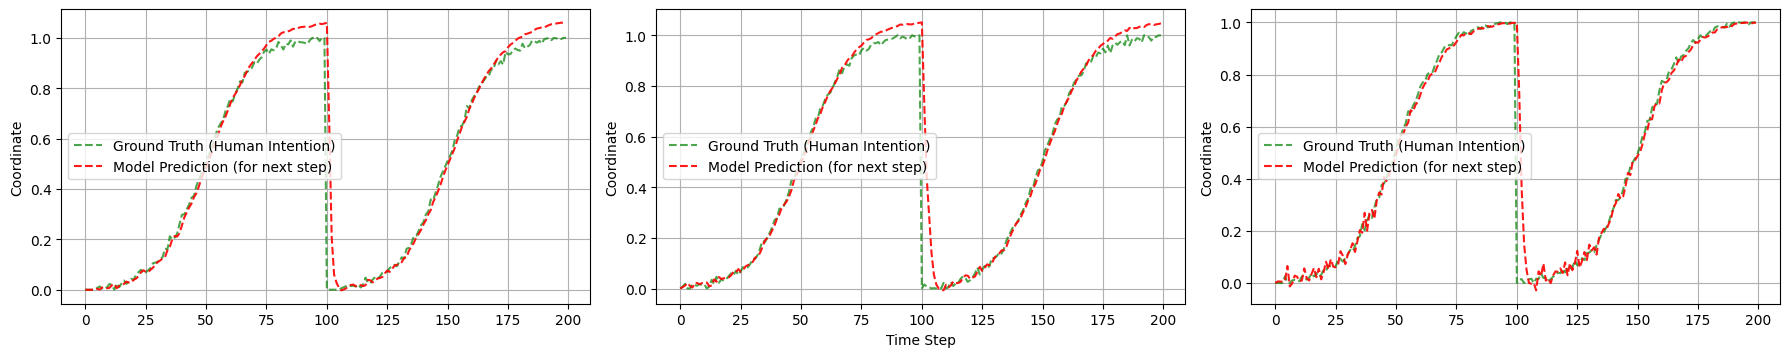

Dự đoán hoàn tất sau 12.7360 giây.
Quỹ đạo : Tổng thời gian dự đoán chuỗi: 12.736002 giây
Quỹ đạo : Thời gian dự đoán trung bình mỗi bước: 0.063102 giây


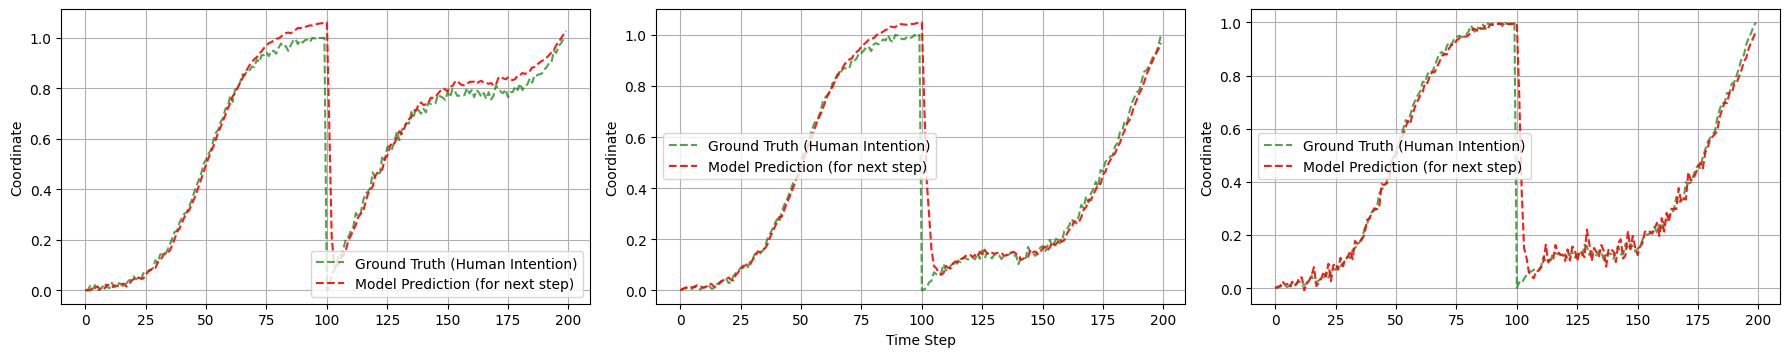

Dự đoán hoàn tất sau 12.5706 giây.
Quỹ đạo : Tổng thời gian dự đoán chuỗi: 12.570606 giây
Quỹ đạo : Thời gian dự đoán trung bình mỗi bước: 0.062272 giây


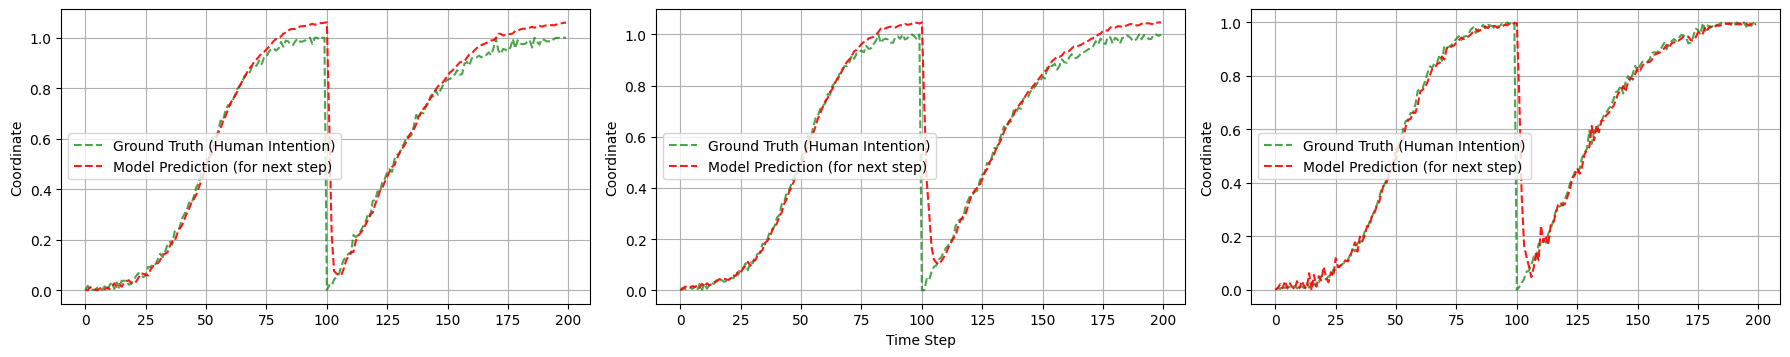

In [ ]:
import time
import pandas as pd # Import pandas

# === Load data ===
# Use the load_data function defined earlier and load the correct test file
data = load_data('/content/drive/MyDrive/Train Model HRC_Trần Văn Duy_20222256/Gated Recurrent Unit/robot_trajectory_randomized_movement.csv')

# Process data into sequences of SEQUENCE_LENGTH
trajectories = []
num_full_sequences = len(data) // SEQUENCE_LENGTH

for i in range(num_full_sequences):
    start_idx = i * SEQUENCE_LENGTH
    end_idx = start_idx + SEQUENCE_LENGTH
    trajectory = data[start_idx:end_idx]
    trajectories.append(trajectory)

# Only convert to numpy array if there are full trajectories
if trajectories:
    trajectories = np.array(trajectories)
else:
    print("No full trajectories found in the test dataset.")
    trajectories = np.array([]) # Create an empty array if no full trajectories

# === Use the trained model and scalers directly ===
# The model, scaler_x, and scaler_y are available in the current session after training.
# No need to load them from files.

# === Đánh giá mô hình trên dữ liệu test ===
# Use the create_seq2one_data function defined earlier
if len(trajectories) > 0:
    # Flatten the trajectories back to a 2D array as expected by create_seq2one_data for this model
    data_flat = trajectories.reshape(-1, NUM_FEATURES)
    inputs, targets = create_data(data_flat, T, SEQUENCE_LENGTH)
    inputs_scaled, targets_scaled, _, _ = scale_data(inputs, targets) # Scale the inputs and targets
    loss = model.evaluate(inputs_scaled, targets_scaled, verbose=0)
    print(f"Loss on test data: {loss:}")
else:
    print("No trajectories available for evaluation.")


# Vẽ ngẫu nhiên 5 đồ thị
NUM_PLOTS = 5
# Ensure we don't try to plot more trajectories than available
num_trajectories_to_plot = min(NUM_PLOTS, len(trajectories))

for i in range(num_trajectories_to_plot):
    #Chọn 1 cách ngẫu nhiên
    random_index = np.random.randint(0, len(trajectories))
    trajectory = trajectories[random_index]
    # trajectory = trajectories[i] # Removed redundant line
    ground_truth_seq = trajectory.copy()

    # === Dự đoán online ===
    predicted_seq, prediction_times, total_prediction_time = predict_assistive_gt_input_from_zero(
        model, scaler_x, scaler_y, ground_truth=ground_truth_seq # Truyền ground_truth luôn
    )

    # === In kết quả và vẽ ===
    print(f"Quỹ đạo : Tổng thời gian dự đoán chuỗi: {total_prediction_time:.6f} giây")
    print(f"Quỹ đạo : Thời gian dự đoán trung bình mỗi bước: {np.mean(prediction_times):.6f} giây")
    plot_assistive_prediction_3d(ground_truth_seq, predicted_seq)

## Test with new dataset

Số lượng quỹ đạo: 40
Shape của X: (8000, 20, 3)
Shape của y: (8000, 3)
Loss trên dữ liệu test: 8.75554615049623e-05
MAE trên dữ liệu test: 0.006699906662106514
Dự đoán hoàn tất sau 13.9320 giây.
Quỹ đạo : Tổng thời gian dự đoán chuỗi: 13.931982 giây
Quỹ đạo : Thời gian dự đoán trung bình mỗi bước: 0.069057 giây


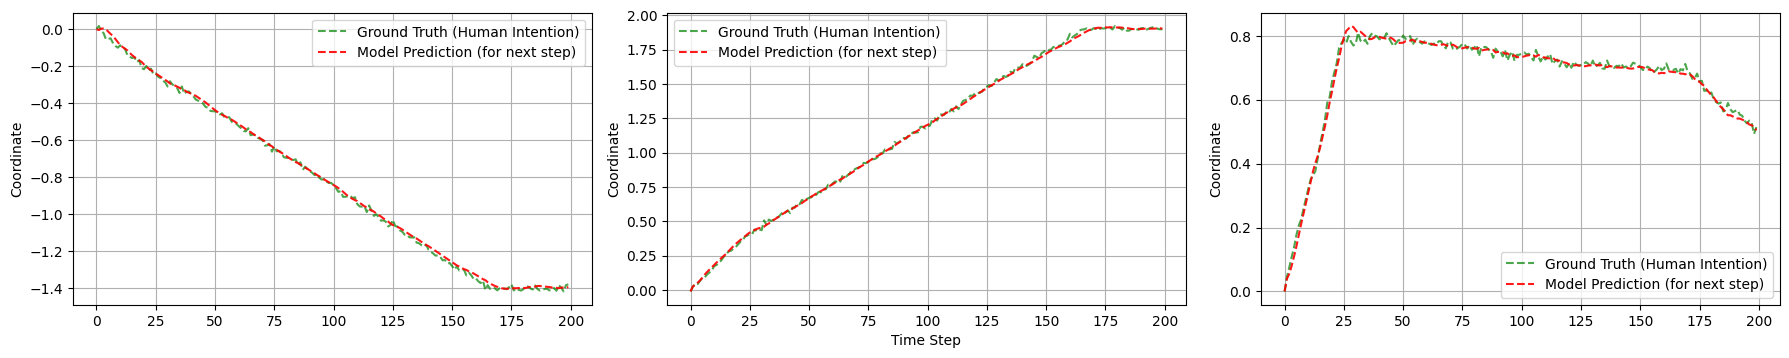

Dự đoán hoàn tất sau 12.4142 giây.
Quỹ đạo : Tổng thời gian dự đoán chuỗi: 12.414204 giây
Quỹ đạo : Thời gian dự đoán trung bình mỗi bước: 0.061468 giây


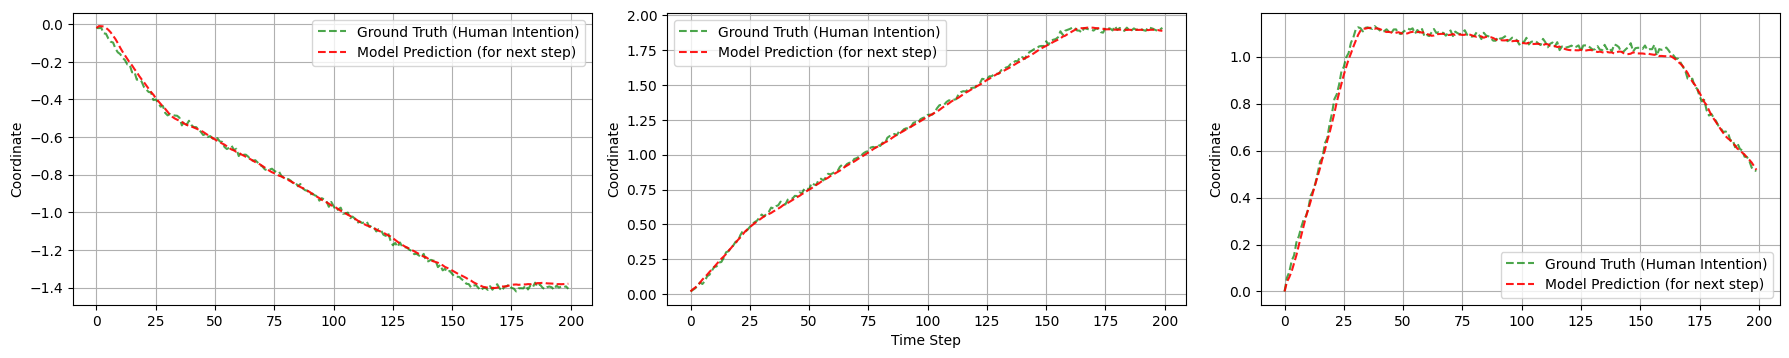

Dự đoán hoàn tất sau 13.9126 giây.
Quỹ đạo : Tổng thời gian dự đoán chuỗi: 13.912609 giây
Quỹ đạo : Thời gian dự đoán trung bình mỗi bước: 0.068933 giây


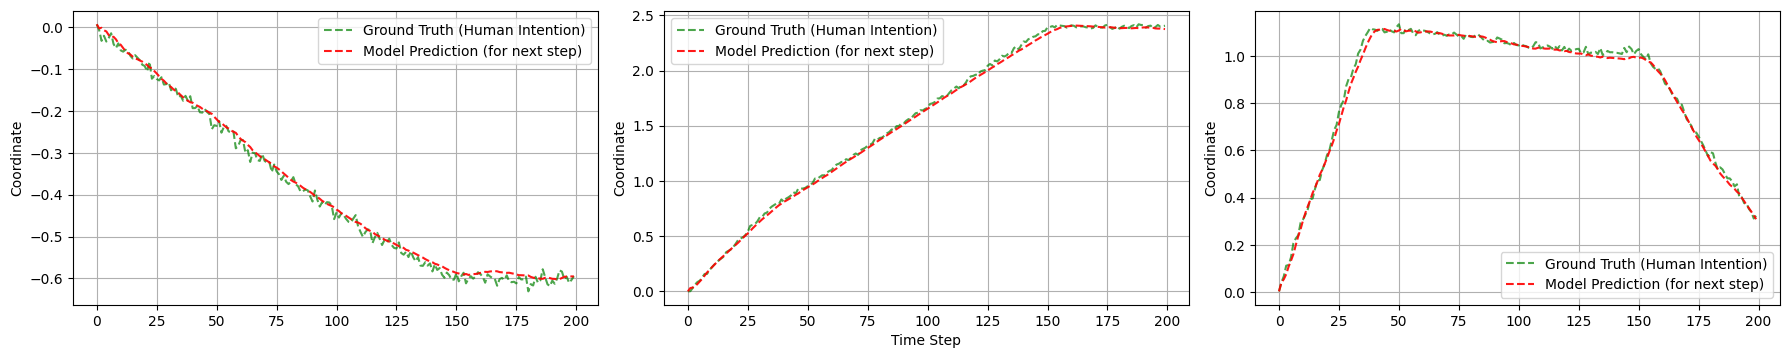

Dự đoán hoàn tất sau 12.8802 giây.
Quỹ đạo : Tổng thời gian dự đoán chuỗi: 12.880189 giây
Quỹ đạo : Thời gian dự đoán trung bình mỗi bước: 0.063791 giây


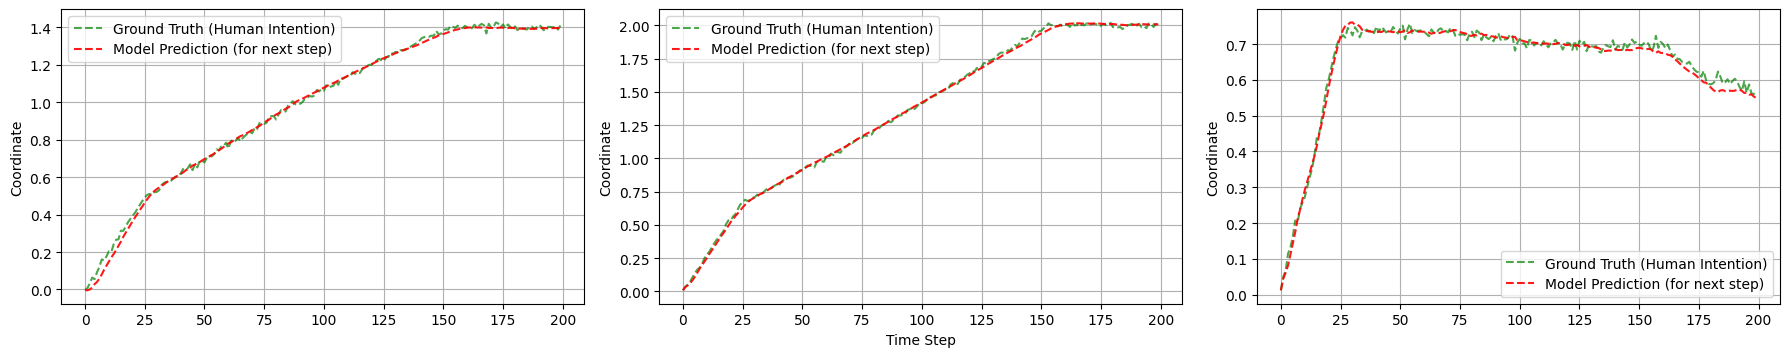

Dự đoán hoàn tất sau 13.2949 giây.
Quỹ đạo : Tổng thời gian dự đoán chuỗi: 13.294939 giây
Quỹ đạo : Thời gian dự đoán trung bình mỗi bước: 0.065887 giây


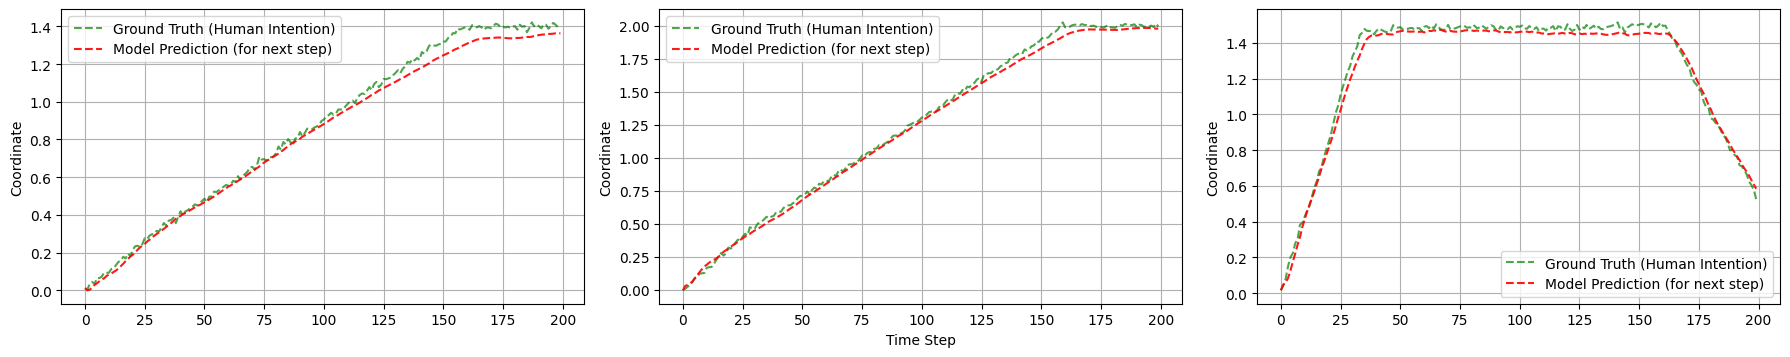

In [ ]:
import time
import pandas as pd # Import pandas
import numpy as np
import matplotlib.pyplot as plt # Import matplotlib for plotting
import pickle
from tensorflow.keras.models import load_model
from tensorflow.keras.losses import MeanSquaredError # Import MSE loss

# === Load data, mô hình, scaler ===
# Use the load_data function defined earlier and load the correct test file
data = load_data('/content/drive/MyDrive/Train Model HRC_Trần Văn Duy_20222256/Gated Recurrent Unit/conference paper/data_test.csv')
SCALER_X_PATH_1 = '/content/drive/MyDrive/Train Model HRC_Trần Văn Duy_20222256/Gated Recurrent Unit/conference paper/scaler_x.pkl'
SCALER_Y_PATH_1 = '/content/drive/MyDrive/Train Model HRC_Trần Văn Duy_20222256/Gated Recurrent Unit/conference paper/scaler_y.pkl'
MODEL_PATH = '/content/drive/MyDrive/Train Model HRC_Trần Văn Duy_20222256/Gated Recurrent Unit/conference paper/gru_model_1_layers.h5'
# Process data into sequences of SEQUENCE_LENGTH
trajectories = []
num_full_sequences = len(data) // SEQUENCE_LENGTH

for i in range(num_full_sequences):
    start_idx = i * SEQUENCE_LENGTH
    end_idx = start_idx + SEQUENCE_LENGTH
    trajectory = data[start_idx:end_idx]
    trajectories.append(trajectory)

# Only convert to numpy array if there are full trajectories
if trajectories:
    trajectories = np.array(trajectories)
else:
    print("No full trajectories found in the test dataset.")
    trajectories = np.array([]) # Create an empty array if no full trajectories

# Load the model explicitly providing the custom object for the loss
model = load_model(MODEL_PATH, custom_objects={'mse': MeanSquaredError()})

# Re-compile the model with metrics after loading
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

scaler_x = pickle.load(open(SCALER_X_PATH_1, 'rb'))
scaler_y = pickle.load(open(SCALER_Y_PATH_1, 'rb'))

# === Đánh giá mô hình trên dữ liệu test ===
# Use the create_seq2one_data function defined earlier
if len(trajectories) > 0:
    # Flatten the trajectories back to a 2D array as expected by create_seq2one_data for this model
    data_flat = trajectories.reshape(-1, NUM_FEATURES)
    inputs, targets = create_data(data_flat, T, SEQUENCE_LENGTH)
    inputs_scaled, targets_scaled, _, _ = scale_data(inputs, targets) # Scale the inputs and targets
    loss, mae = model.evaluate(inputs_scaled, targets_scaled, verbose=0) # Get both loss and mae
    print(f"Loss trên dữ liệu test: {loss:}") # Updated print statement
    print(f"MAE trên dữ liệu test: {mae:}") # Print MAE
else:
    print("No trajectories available for evaluation.")


# Vẽ ngẫu nhiên 5 đồ thị
NUM_PLOTS = 5
# Ensure we don't try to plot more trajectories than available
num_trajectories_to_plot = min(NUM_PLOTS, len(trajectories))

for i in range(num_trajectories_to_plot):
    #Chọn 1 cách ngẫu nhiên
    random_index = np.random.randint(0, len(trajectories))
    trajectory = trajectories[random_index]
    # trajectory = trajectories[i] # Removed redundant line
    ground_truth_seq = trajectory.copy()

    # === Dự đoán online ===
    predicted_seq, prediction_times, total_prediction_time = predict_assistive_gt_input_from_zero(
        model, scaler_x, scaler_y, ground_truth=ground_truth_seq # Truyền ground_truth luôn
    )

    # === In kết quả và vẽ ===
    print(f"Quỹ đạo : Tổng thời gian dự đoán chuỗi: {total_prediction_time:.6f} giây")
    print(f"Quỹ đạo : Thời gian dự đoán trung bình mỗi bước: {np.mean(prediction_times):.6f} giây")
    plot_assistive_prediction_3d(ground_truth_seq, predicted_seq)

# Ablation study

Số lượng quỹ đạo: 200
Shape của X: (40000, 50, 3)
Shape của y: (40000, 3)
BẮT ĐẦU ABLATION STUDY: So sánh 5 models với 1-5 lớp GRU

MODEL 1: 1 lớp GRU

Kiến trúc model:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_18 (GRU)                    │ (None, 256)            │       200,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,219 (786.01 KB)

...

 Total params: 401,763 (1.53 MB)

 Trainable params: 401,763 (1.53 MB)

 Non-trainable params: 0 (0.00 B)


Tổng số parameters: 401,763
  - Trainable: 401,763
  - Non-trainable: 0

🚀 Bắt đầu huấn luyện...
Epoch 1/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 0.0329 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 2/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.0078 - val_loss: 6.3502e-04 - learning_rate: 0.0010
Epoch 3/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0056 - val_loss: 5.3469e-04 - learning_rate: 0.0010
Epoch 4/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0044 - val_loss: 4.9186e-04 - learning_rate: 0.0010
Epoch 5/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.0037 - val_loss: 4.8481e-04 - learning_rate: 0.0010
Epoch 6/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.0034 - val_loss: 3.2888e-04 - learning_rate: 0.0010
Epoch 7/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0032 - val_loss: 9.8544e-04 - learning_rate: 0.0010
Epoch 8/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 0.0031 - val_loss: 7.3733e-04


✅ Model đã lưu: gru_model_5_layers.h5

📊 KẾT QUẢ:
  - Train Loss: 0.000195
  - Val Loss: 0.000192
  - Best Val Loss: 0.000192
  - Training Time: 588.26s
  - Inference Time: 5.9207ms/sample
  - Model Size: 4.67MB

BẢNG SO SÁNH CHI TIẾT CÁC MODELS
 num_layers total_params  trainable_params train_loss val_loss best_val_loss training_time_sec inference_time_ms model_size_mb  epochs_trained overfit_ratio  params_per_mb
          1      201,219            201219   0.000136 0.000134      0.000134           285.52s          1.8915ms        2.33MB              88         0.987   86275.549868
          2      349,059            349059   0.000141 0.000139      0.000139           456.04s          2.8933ms        4.03MB              88         0.985   86554.534229
          3      386,115            386115   0.000155 0.000152      0.000152           512.44s          3.8724ms        4.46MB              79         0.984   86482.201253
          4      395,427            395427   0.000233 0.000231   

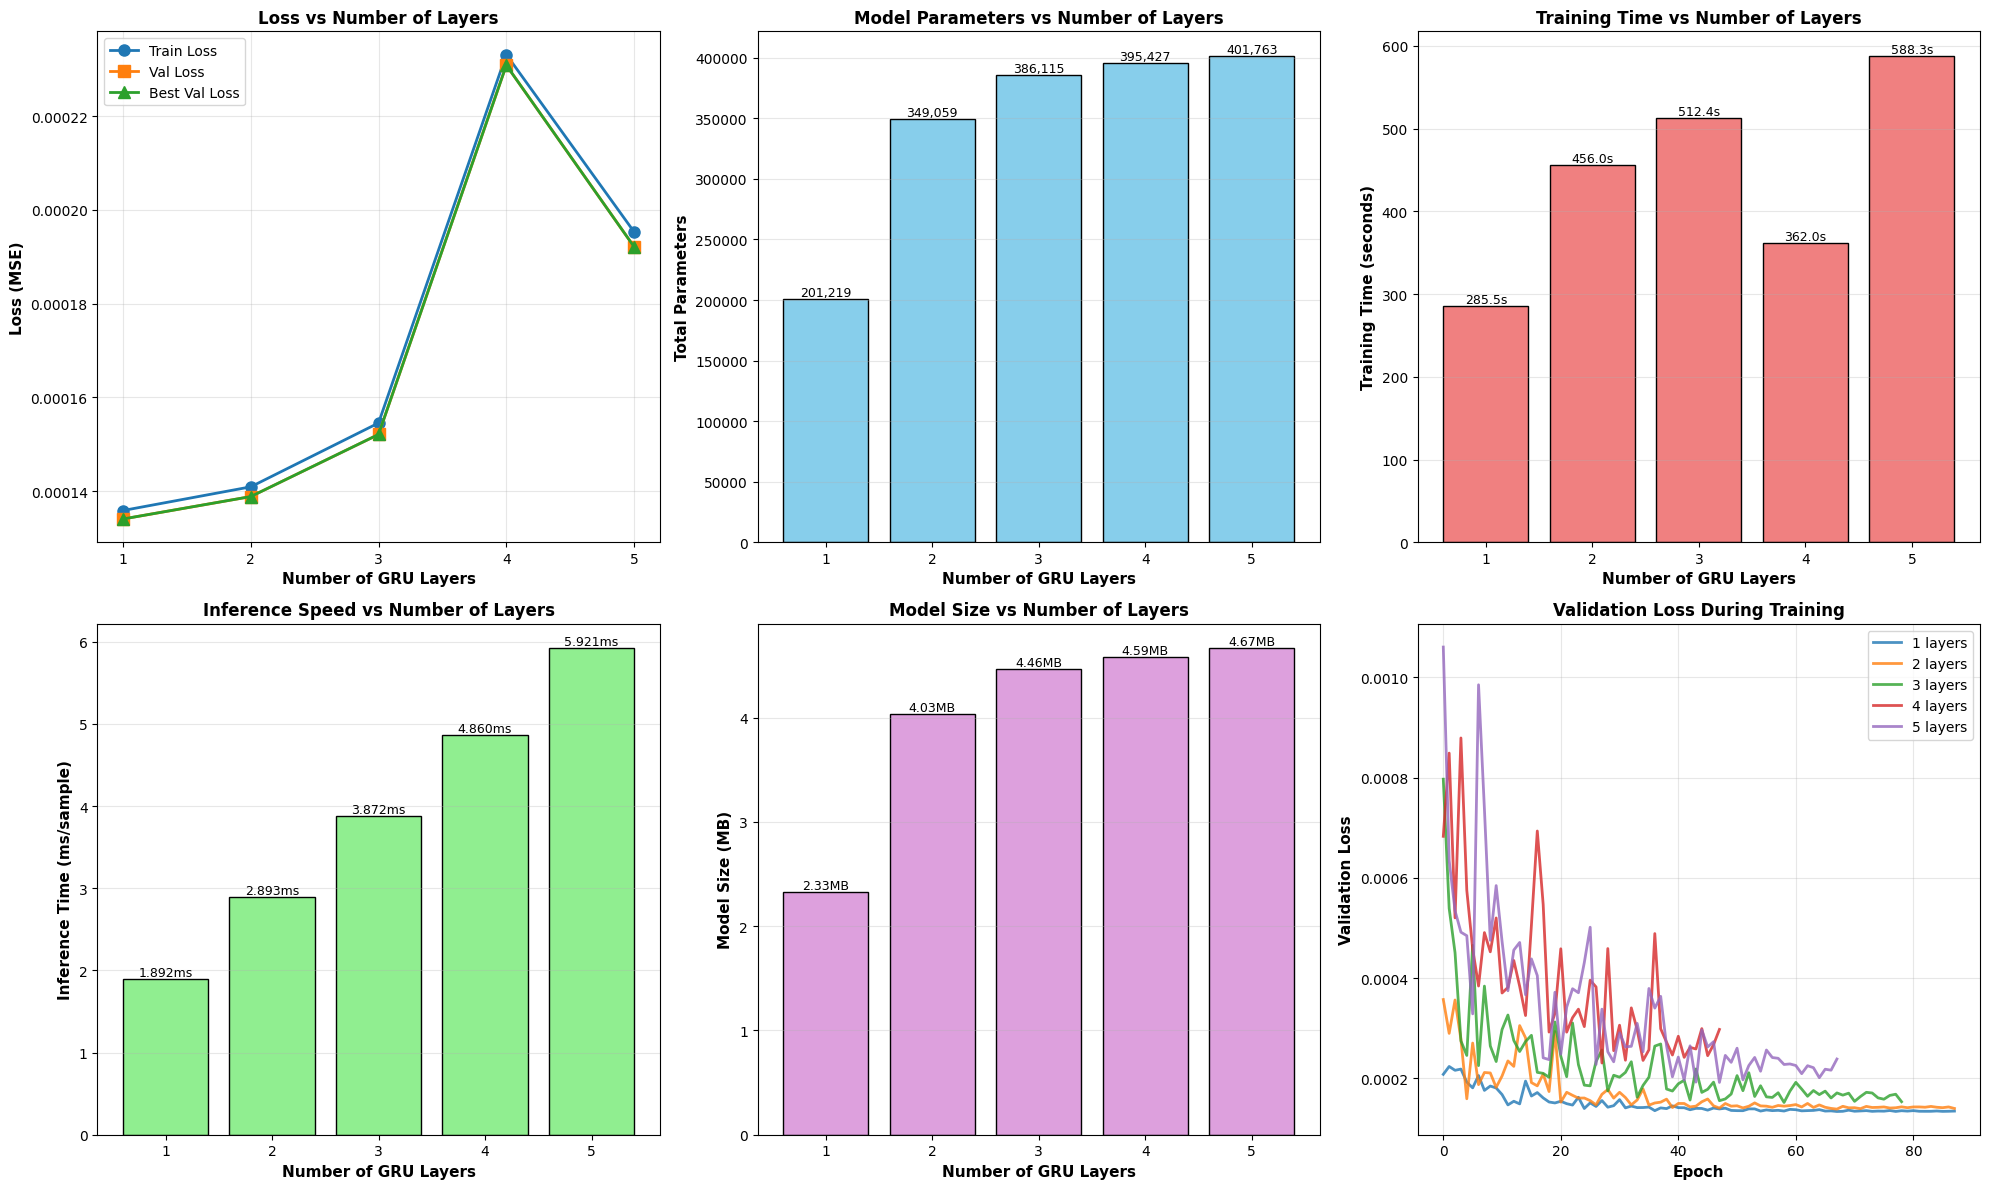

In [ ]:
import numpy as np
import pandas as pd
import pickle
import time
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Tham số
NUM_FEATURES=3
T = 50             # Input length
PRED_STEPS = 150    # Số bước cần dự đoán
MODEL_PATH = 'Deep_GRU.keras'
SCALER_X_PATH_1 = 'scaler_x.pkl'
SCALER_Y_PATH_1 = 'scaler_y.pkl'
SEQUENCE_LENGTH = T + PRED_STEPS

def load_data(file_path):
    df = pd.read_csv(file_path)
    return df[['x', 'y', 'z']].values

def create_data(data, T, sequence_length):
    X, y = [], []
    num_trajectories = len(data) // sequence_length
    print(f"Số lượng quỹ đạo: {num_trajectories}")

    for i in range(num_trajectories):
        # Lấy dữ liệu cho quỹ đạo thứ i
        trajectory = data[i*sequence_length : (i+1)*sequence_length]

        # Kiểm tra kích thước
        if trajectory.shape != (sequence_length, 3):
            continue

        # Tạo các chuỗi đầu vào và đầu ra từ quỹ đạo
        for j in range(sequence_length):
            if j < T:
                # Với t < T: pad zero vào phía trước
                num_zeros = T - j  # Số zero vectors cần thêm
                num_real_points = j  # Số điểm thực có

                # Tạo zero padding
                zero_padding = np.zeros((num_zeros, 3))

                # Lấy các điểm thực từ đầu quỹ đạo đến j-1
                if num_real_points > 0:
                    real_points = trajectory[0:j]
                    input_sequence = np.vstack([zero_padding, real_points])
                else:
                    # Trường hợp j=0, chỉ có zero padding
                    input_sequence = zero_padding

                # Output là điểm tiếp theo
                output_point = trajectory[j]

            else:
                # Với t >= T: lấy T điểm liên tiếp như bình thường
                input_sequence = trajectory[j-T:j]
                output_point = trajectory[j]

            X.append(input_sequence)
            y.append(output_point)

    X = np.array(X)
    y = np.array(y)

    print(f"Shape của X: {X.shape}")  # (num_samples, T, 3)
    print(f"Shape của y: {y.shape}")  # (num_samples, 3)

    return X, y

def scale_data(X, y):
    """
    Scale riêng từng trục (x, y, z) để đảm bảo mỗi trục có range [0, 1]

    Args:
        X: (num_samples, T, 3) - input sequences
        y: (num_samples, 3) - target positions

    Returns:
        X_scaled, y_scaled, scaler_x, scaler_y
    """
    # Tạo 3 scalers riêng biệt cho 3 trục
    scaler_x = {
        'x': MinMaxScaler(),
        'y': MinMaxScaler(),
        'z': MinMaxScaler()
    }

    scaler_y = {
        'x': MinMaxScaler(),
        'y': MinMaxScaler(),
        'z': MinMaxScaler()
    }

    # Scale X (input sequences) - từng trục riêng biệt
    X_scaled = X.copy()
    num_samples, T, _ = X.shape

    # Scale trục X (chiều 0)
    X_scaled[:, :, 0] = scaler_x['x'].fit_transform(X[:, :, 0].reshape(-1, 1)).reshape(num_samples, T)
    # Scale trục Y (chiều 1)
    X_scaled[:, :, 1] = scaler_x['y'].fit_transform(X[:, :, 1].reshape(-1, 1)).reshape(num_samples, T)
    # Scale trục Z (chiều 2)
    X_scaled[:, :, 2] = scaler_x['z'].fit_transform(X[:, :, 2].reshape(-1, 1)).reshape(num_samples, T)

    # Scale y (target) - từng trục riêng biệt
    y_scaled = y.copy()
    y_scaled[:, 0] = scaler_y['x'].fit_transform(y[:, 0].reshape(-1, 1)).ravel()
    y_scaled[:, 1] = scaler_y['y'].fit_transform(y[:, 1].reshape(-1, 1)).ravel()
    y_scaled[:, 2] = scaler_y['z'].fit_transform(y[:, 2].reshape(-1, 1)).ravel()

    return X_scaled, y_scaled, scaler_x, scaler_y

def build_gru_model(input_shape, num_layers, units_list=None):
    """
    Xây dựng model GRU với số lớp tùy chỉnh

    Args:
        input_shape: tuple (T, 3) - shape của input
        num_layers: int - số lớp GRU (1-5)
        units_list: list - số units cho mỗi lớp. Nếu None, dùng mặc định giảm dần

    Returns:
        model: Keras Sequential model
    """
    # Mặc định: giảm dần số units theo các lớp
    if units_list is None:
        base_units = 256
        units_list = [base_units // (2**i) for i in range(num_layers)]
        # Đảm bảo lớp cuối không quá nhỏ
        units_list = [max(u, 32) for u in units_list]

    model = Sequential()

    # Thêm các lớp GRU
    for i in range(num_layers):
        if i == 0:
            # Lớp đầu tiên cần input_shape
            if num_layers == 1:
                # Nếu chỉ 1 lớp, không return sequences
                model.add(GRU(units_list[i], activation='tanh', input_shape=input_shape))
            else:
                # Nếu nhiều lớp, return sequences cho các lớp trừ lớp cuối
                model.add(GRU(units_list[i], activation='tanh', return_sequences=True, input_shape=input_shape))
        else:
            if i == num_layers - 1:
                # Lớp cuối cùng không return sequences
                model.add(GRU(units_list[i], activation='tanh'))
            else:
                # Các lớp giữa return sequences
                model.add(GRU(units_list[i], activation='tanh', return_sequences=True))

        # Thêm Dropout sau mỗi lớp GRU
        model.add(Dropout(0.3))

    # Lớp output
    model.add(Dense(3))

    # Compile model
    model.compile(optimizer=Adam(0.001), loss='mse')

    return model

def get_model_size(model):
    """Tính kích thước model (MB)"""
    # Lưu model tạm thời để tính size
    temp_path = 'temp_model.h5'
    model.save(temp_path)
    size_mb = os.path.getsize(temp_path) / (1024 * 1024)
    os.remove(temp_path)
    return size_mb

def count_parameters(model):
    """Đếm số parameters trong model"""
    trainable = int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))
    non_trainable = int(np.sum([np.prod(v.shape) for v in model.non_trainable_weights]))
    return trainable, non_trainable

def run_ablation_study(X_train, y_train, X_val, y_val, max_layers=5, epochs=100, batch_size=32):
    """
    Chạy ablation study cho các model với số lớp GRU khác nhau

    Args:
        X_train, y_train: Training data
        X_val, y_val: Validation data
        max_layers: Số lớp tối đa để test (1 đến max_layers)
        epochs: Số epochs huấn luyện
        batch_size: Batch size

    Returns:
        results_df: DataFrame chứa kết quả so sánh
        models_dict: Dictionary chứa các models đã huấn luyện
        histories_dict: Dictionary chứa training histories
    """

    input_shape = (X_train.shape[1], X_train.shape[2])  # (T, 3)

    results = []
    models_dict = {}
    histories_dict = {}

    print("="*80)
    print(f"BẮT ĐẦU ABLATION STUDY: So sánh {max_layers} models với 1-{max_layers} lớp GRU")
    print("="*80)

    for num_layers in range(1, max_layers + 1):
        print(f"\n{'='*80}")
        print(f"MODEL {num_layers}: {num_layers} lớp GRU")
        print(f"{'='*80}")

        # Build model
        model = build_gru_model(input_shape, num_layers)

        # In thông tin model
        print("\nKiến trúc model:")
        model.summary()

        # Đếm parameters
        trainable_params, non_trainable_params = count_parameters(model)
        total_params = trainable_params + non_trainable_params
        print(f"\nTổng số parameters: {total_params:,}")
        print(f"  - Trainable: {trainable_params:,}")
        print(f"  - Non-trainable: {non_trainable_params:,}")

        # Callbacks
        early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)

        # Training
        print(f"\n🚀 Bắt đầu huấn luyện...")
        start_time = time.time()

        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop, reduce_lr],
            verbose=1
        )

        training_time = time.time() - start_time

        # Evaluate
        train_loss = model.evaluate(X_train, y_train, verbose=0)
        val_loss = model.evaluate(X_val, y_val, verbose=0)

        # Tính thời gian inference (trung bình trên 100 samples)
        test_samples = X_val[:100]
        inference_start = time.time()
        _ = model.predict(test_samples, verbose=0)
        inference_time = (time.time() - inference_start) / 100 * 1000  # ms per sample

        # Tính kích thước model
        model_size_mb = get_model_size(model)

        # Lưu kết quả
        result = {
            'num_layers': num_layers,
            'total_params': total_params,
            'trainable_params': trainable_params,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'best_val_loss': min(history.history['val_loss']),
            'training_time_sec': training_time,
            'inference_time_ms': inference_time,
            'model_size_mb': model_size_mb,
            'epochs_trained': len(history.history['loss'])
        }
        results.append(result)

        # Lưu model và history
        models_dict[f'model_{num_layers}_layers'] = model
        histories_dict[f'model_{num_layers}_layers'] = history

        # Lưu model vào file
        model_path = f'gru_model_{num_layers}_layers.h5'
        model.save(model_path)
        print(f"\n✅ Model đã lưu: {model_path}")

        print(f"\n📊 KẾT QUẢ:")
        print(f"  - Train Loss: {train_loss:.6f}")
        print(f"  - Val Loss: {val_loss:.6f}")
        print(f"  - Best Val Loss: {result['best_val_loss']:.6f}")
        print(f"  - Training Time: {training_time:.2f}s")
        print(f"  - Inference Time: {inference_time:.4f}ms/sample")
        print(f"  - Model Size: {model_size_mb:.2f}MB")

    # Tạo DataFrame kết quả
    results_df = pd.DataFrame(results)

    # Tính các metrics bổ sung
    results_df['overfit_ratio'] = results_df['val_loss'] / results_df['train_loss']
    results_df['params_per_mb'] = results_df['total_params'] / results_df['model_size_mb']

    return results_df, models_dict, histories_dict

def visualize_results(results_df, histories_dict):
    """Trực quan hóa kết quả ablation study"""

    fig = plt.figure(figsize=(20, 12))

    # 1. Loss comparison
    ax1 = plt.subplot(2, 3, 1)
    x = results_df['num_layers']
    ax1.plot(x, results_df['train_loss'], marker='o', linewidth=2, markersize=8, label='Train Loss')
    ax1.plot(x, results_df['val_loss'], marker='s', linewidth=2, markersize=8, label='Val Loss')
    ax1.plot(x, results_df['best_val_loss'], marker='^', linewidth=2, markersize=8, label='Best Val Loss')
    ax1.set_xlabel('Number of GRU Layers', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Loss (MSE)', fontsize=11, fontweight='bold')
    ax1.set_title('Loss vs Number of Layers', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(x)

    # 2. Parameters comparison
    ax2 = plt.subplot(2, 3, 2)
    bars = ax2.bar(x, results_df['total_params'], color='skyblue', edgecolor='black')
    ax2.set_xlabel('Number of GRU Layers', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Total Parameters', fontsize=11, fontweight='bold')
    ax2.set_title('Model Parameters vs Number of Layers', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_xticks(x)
    # Thêm labels trên bars
    for bar, val in zip(bars, results_df['total_params']):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(val):,}', ha='center', va='bottom', fontsize=9)

    # 3. Training time comparison
    ax3 = plt.subplot(2, 3, 3)
    bars = ax3.bar(x, results_df['training_time_sec'], color='lightcoral', edgecolor='black')
    ax3.set_xlabel('Number of GRU Layers', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Training Time (seconds)', fontsize=11, fontweight='bold')
    ax3.set_title('Training Time vs Number of Layers', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.set_xticks(x)
    for bar, val in zip(bars, results_df['training_time_sec']):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.1f}s', ha='center', va='bottom', fontsize=9)

    # 4. Inference time comparison
    ax4 = plt.subplot(2, 3, 4)
    bars = ax4.bar(x, results_df['inference_time_ms'], color='lightgreen', edgecolor='black')
    ax4.set_xlabel('Number of GRU Layers', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Inference Time (ms/sample)', fontsize=11, fontweight='bold')
    ax4.set_title('Inference Speed vs Number of Layers', fontsize=12, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='y')
    ax4.set_xticks(x)
    for bar, val in zip(bars, results_df['inference_time_ms']):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}ms', ha='center', va='bottom', fontsize=9)

    # 5. Model size comparison
    ax5 = plt.subplot(2, 3, 5)
    bars = ax5.bar(x, results_df['model_size_mb'], color='plum', edgecolor='black')
    ax5.set_xlabel('Number of GRU Layers', fontsize=11, fontweight='bold')
    ax5.set_ylabel('Model Size (MB)', fontsize=11, fontweight='bold')
    ax5.set_title('Model Size vs Number of Layers', fontsize=12, fontweight='bold')
    ax5.grid(True, alpha=0.3, axis='y')
    ax5.set_xticks(x)
    for bar, val in zip(bars, results_df['model_size_mb']):
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.2f}MB', ha='center', va='bottom', fontsize=9)

    # 6. Training history for all models
    ax6 = plt.subplot(2, 3, 6)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    for i, (name, history) in enumerate(histories_dict.items()):
        num_layers = int(name.split('_')[1])
        ax6.plot(history.history['val_loss'], label=f'{num_layers} layers',
                color=colors[i], linewidth=2, alpha=0.8)
    ax6.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax6.set_ylabel('Validation Loss', fontsize=11, fontweight='bold')
    ax6.set_title('Validation Loss During Training', fontsize=12, fontweight='bold')
    ax6.legend(fontsize=10)
    ax6.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('ablation_study_results.png', dpi=150, bbox_inches='tight')
    plt.show()

def print_comparison_table(results_df):
    """In bảng so sánh chi tiết"""
    print("\n" + "="*120)
    print("BẢNG SO SÁNH CHI TIẾT CÁC MODELS")
    print("="*120)

    # Format DataFrame để hiển thị đẹp
    display_df = results_df.copy()
    display_df['train_loss'] = display_df['train_loss'].apply(lambda x: f"{x:.6f}")
    display_df['val_loss'] = display_df['val_loss'].apply(lambda x: f"{x:.6f}")
    display_df['best_val_loss'] = display_df['best_val_loss'].apply(lambda x: f"{x:.6f}")
    display_df['overfit_ratio'] = display_df['overfit_ratio'].apply(lambda x: f"{x:.3f}")
    display_df['training_time_sec'] = display_df['training_time_sec'].apply(lambda x: f"{x:.2f}s")
    display_df['inference_time_ms'] = display_df['inference_time_ms'].apply(lambda x: f"{x:.4f}ms")
    display_df['model_size_mb'] = display_df['model_size_mb'].apply(lambda x: f"{x:.2f}MB")
    display_df['total_params'] = display_df['total_params'].apply(lambda x: f"{x:,}")

    print(display_df.to_string(index=False))
    print("="*120)

from sklearn.model_selection import train_test_split # Import train_test_split

data = load_data('/content/drive/MyDrive/Train Model HRC_Trần Văn Duy_20222256/Gated Recurrent Unit/conference paper/human_robot_cocarrying_trajectories.csv')
X, y = create_data(data, T, SEQUENCE_LENGTH)
X_scaled, y_scaled, scaler_x, scaler_y = scale_data(X, y)
X_train, X_val, y_train, y_val = train_test_split(
        X_scaled,               # Dữ liệu input đầy đủ đã scale
        y_scaled,               # Dữ liệu output đầy đủ đã scale
        test_size=0.2,          # 20% cho validation
        random_state=42,        # Để kết quả lặp lại được
        shuffle=True            # Xáo trộn dữ liệu
    )

# 1. Chạy ablation study
results_df, models_dict, histories_dict = run_ablation_study(
    X_train, y_train,
    X_val, y_val,
    max_layers=5,
    epochs=100,
    batch_size=64
)

# 2. In bảng so sánh
print_comparison_table(results_df)

# 3. Trực quan hóa kết quả
visualize_results(results_df, histories_dict)